### read  3.1, do lab exercise on linear regression, play with college & boston dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
boston = pd.read_csv('Boston.csv', index_col = 0)
boston

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
502,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
503,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
504,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9
505,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,6.48,22.0


### I had Chat make a codebook so we can fully understand each predictor

**crim** – Per capita crime rate by town
→ Higher values = more crime

**zn** – Proportion of residential land zoned for lots over 25,000 sq.ft
→ Measures low-density zoning

**indus** – Proportion of non-retail business acres per town
→ Indicates industrial/commercial activity

**chas** – Charles River dummy variable
→ 1 if tract bounds the river, 0 otherwise

**nox** – Nitric oxides concentration (parts per 10 million)
→ Proxy for air pollution

**rm** – Average number of rooms per dwelling
→ Rough indicator of house size/quality

**age** – Proportion of owner-occupied units built before 1940
→ Older housing stock = higher value

**dis** – Weighted distances to five Boston employment centers
→ Lower = closer to jobs

**rad** – Index of accessibility to radial highways
→ Higher = better highway access

**tax** – Full-value property tax rate per $10,000
→ Higher = higher taxes

**ptratio** – Pupil–teacher ratio by town
→ Higher = larger class sizes

**lstat** – % lower-status population
→ Socioeconomic indicator

**medv** – Median value of owner-occupied homes (in $10,000s)

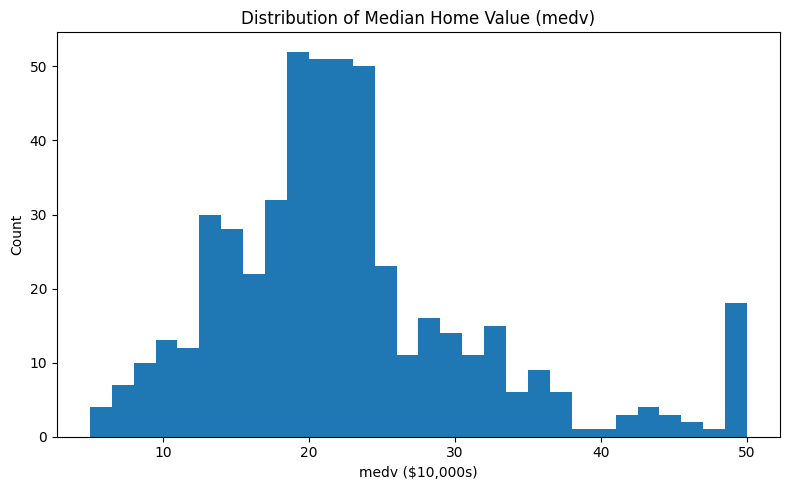

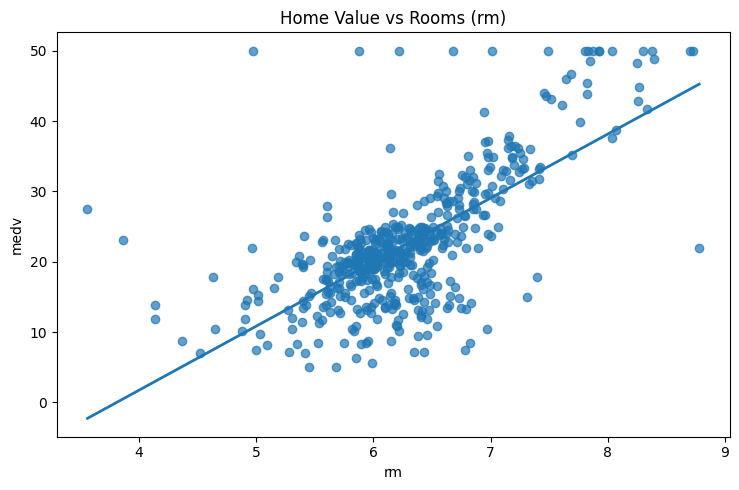

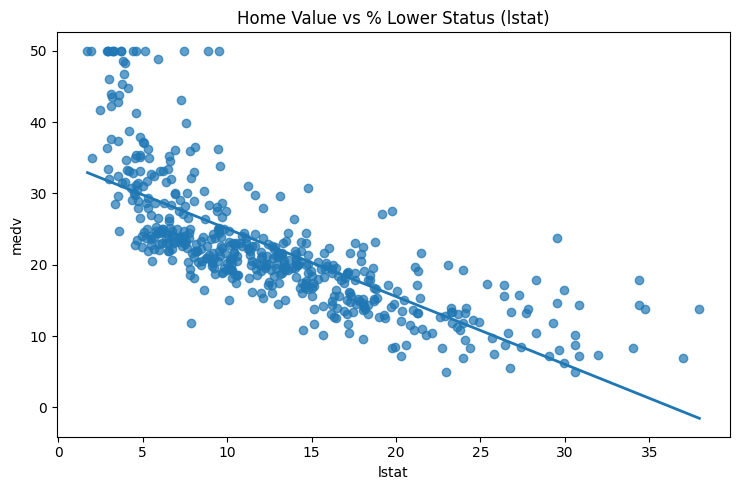

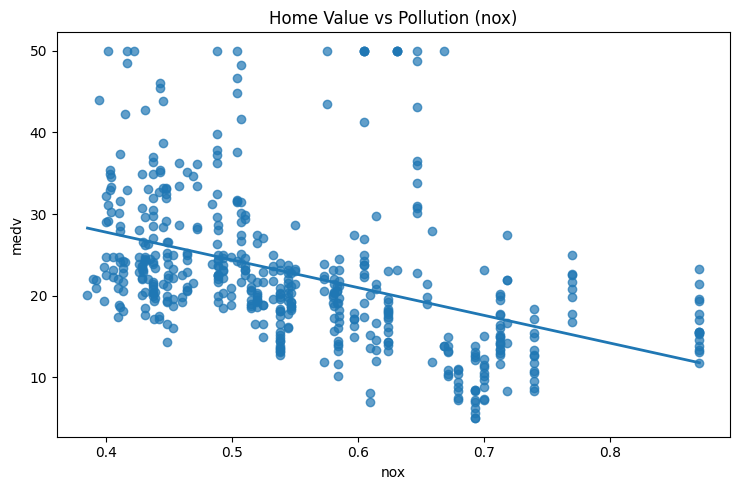

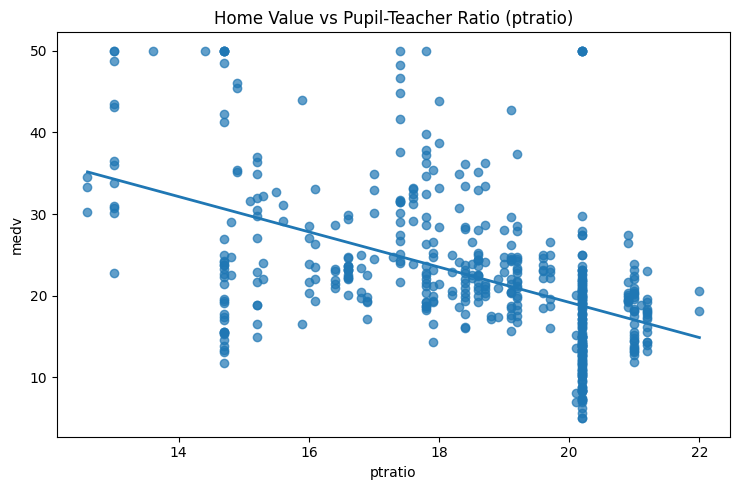

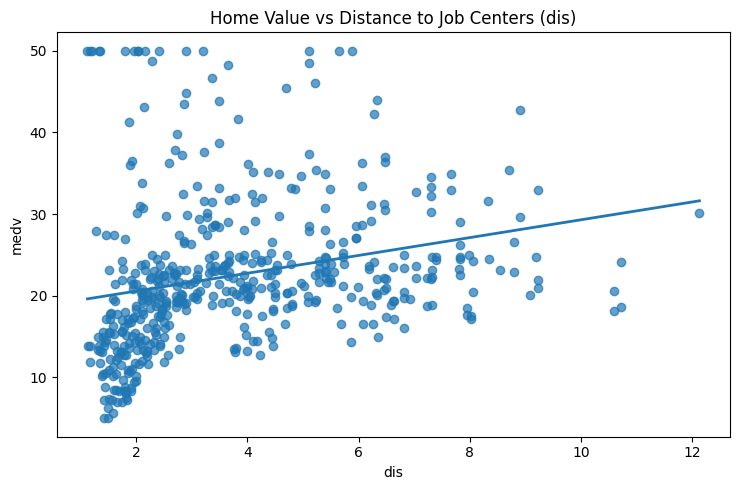

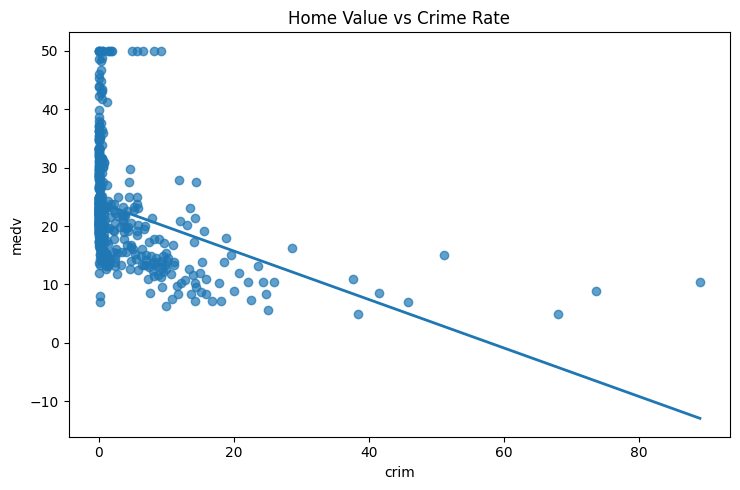

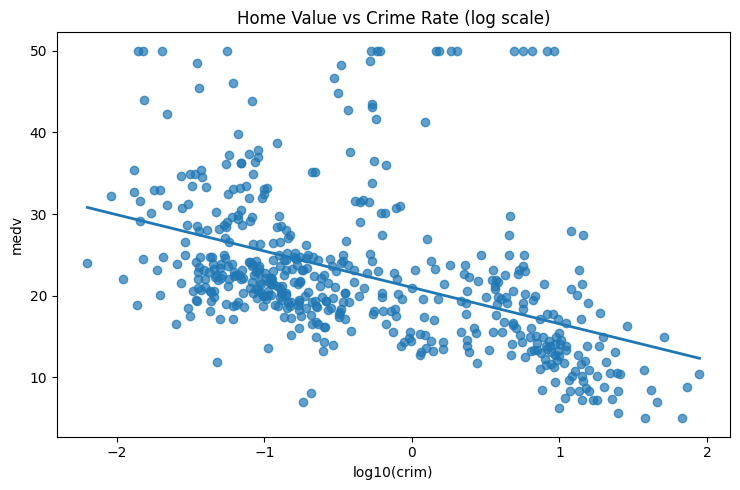

In [13]:
def scatter_with_fit(df, x, y="medv", logx=False, title=None):
    """Scatter plot with a simple least-squares fit line """
    xdata = df[x].to_numpy()
    ydata = df[y].to_numpy()

    mask = np.isfinite(xdata) & np.isfinite(ydata)
    xdata, ydata = xdata[mask], ydata[mask]

    if logx:
        # avoid log of non-positive values
        mask2 = xdata > 0
        xdata, ydata = xdata[mask2], ydata[mask2]
        x_plot = np.log10(xdata)
        xlabel = f"log10({x})"
    else:
        x_plot = xdata
        xlabel = x

    # Fit y = a*x + b
    a, b = np.polyfit(x_plot, ydata, 1)
    xs = np.linspace(x_plot.min(), x_plot.max(), 200)
    ys = a * xs + b

    plt.figure(figsize=(7.5, 5))
    plt.scatter(x_plot, ydata, alpha=0.7)
    plt.plot(xs, ys, linewidth=2)
    plt.xlabel(xlabel)
    plt.ylabel(y)
    plt.title(title if title else f"{y} vs {xlabel} (with fit)")
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(8, 5))
plt.hist(boston["medv"].dropna(), bins=30)
plt.title("Distribution of Median Home Value (medv)")
plt.xlabel("medv ($10,000s)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

scatter_with_fit(boston, "rm",  y="medv", title="Home Value vs Rooms (rm)")
scatter_with_fit(boston, "lstat", y="medv", title="Home Value vs % Lower Status (lstat)")
scatter_with_fit(boston, "nox", y="medv", title="Home Value vs Pollution (nox)")
scatter_with_fit(boston, "ptratio", y="medv", title="Home Value vs Pupil-Teacher Ratio (ptratio)")
scatter_with_fit(boston, "dis", y="medv", title="Home Value vs Distance to Job Centers (dis)")
#normal
scatter_with_fit(boston, "crim", y="medv", title="Home Value vs Crime Rate")
# log scale
scatter_with_fit(boston, "crim", y="medv", logx=True, title="Home Value vs Crime Rate (log scale)")


# MEDV vs predictors

predictors = ["rm", "lstat", "nox", "ptratio", "crim", "tax", "dis", "age"]
n = len(predictors)
cols = 4
rows = int(np.ceil(n / cols))


### I've learned a lot from working with this data
Home value (medv) is correlated to a lot of factors including distance to areas of work, class sizes, air pollution, and crime rate to name a few. I've also learned that most homes fall around the 200,000 dollar value range in Boston. From the spread, I also noticed that there is a decently sized community of houses 500,000 dollars and greater.